# Melanoma Classification — Data Analysis & Preprocessing
This notebook covers:
1. **Balance analysis** — are the classes evenly distributed?
2. **Dataset splitting** — carving a proper val / test split so the test set is never seen during training
3. **Transforms** — augmentation for training, clean resize/crop for evaluation
4. **DataLoaders** — ready to import into the training notebook


## 1 · Imports & configuration

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- Paths ----
BASE_DIR  = Path().resolve()         
DATA_DIR = Path("/Users/raizo/Downloads/melanoma_cancer_dataset")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

assert TRAIN_DIR.exists(), f"Could not find train folder at {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"Could not find test folder at {TEST_DIR}"

# ---- Hyperparameters ----
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 0        
PIN_MEMORY   = torch.cuda.is_available()
VAL_FRACTION = 0.5      # fraction of test/ used for validation

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("Paths OK")
print(f"  train → {TRAIN_DIR}")
print(f"  test  → {TEST_DIR}")


Paths OK
  train → /Users/raizo/Downloads/melanoma_cancer_dataset/train
  test  → /Users/raizo/Downloads/melanoma_cancer_dataset/test


## 2 · Class balance analysis
Before training anything we count images per class in both splits.
The **imbalance ratio** (majority ÷ minority) tells us whether we need
class-weighted loss:

| Ratio | Label | Action |
|-------|-------|--------|
| < 1.5 | Well-balanced | Weights optional but harmless |
| 1.5 – 3.0 | Mildly imbalanced | Apply class weights |
| > 3.0 | Heavily imbalanced | Class weights + consider oversampling |


In [3]:
def count_images(folder: Path) -> dict:
    """Return {class_name: count} for an ImageFolder-style directory."""
    return {
        d.name: len(list(d.glob("*.jpg")))
        for d in sorted(folder.iterdir())
        if d.is_dir() and not d.name.startswith(".")
    }

def imbalance_ratio(counts: dict) -> float:
    v = list(counts.values())
    return max(v) / min(v) if min(v) > 0 else float("inf")

def balance_label(ratio: float) -> str:
    if ratio < 1.5:  return "well-balanced ✓"
    if ratio < 3.0:  return "mildly imbalanced ⚠"
    return "heavily imbalanced ✗"

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)
train_total  = sum(train_counts.values())
test_total   = sum(test_counts.values())
train_ratio  = imbalance_ratio(train_counts)
test_ratio   = imbalance_ratio(test_counts)

print("=" * 55)
print("DATASET BALANCE REPORT")
print("=" * 55)
print(f"\n{'Split':<8} {'Class':<12} {'Count':>6}  {'%':>6}")
print("-" * 36)
for cls, n in train_counts.items():
    print(f"{'train':<8} {cls:<12} {n:>6}  {100*n/train_total:>5.1f}%")
print(f"  total: {train_total}  |  ratio: {train_ratio:.2f}  ({balance_label(train_ratio)})")

print()
for cls, n in test_counts.items():
    print(f"{'test':<8} {cls:<12} {n:>6}  {100*n/test_total:>5.1f}%")
print(f"  total: {test_total}  |  ratio: {test_ratio:.2f}  ({balance_label(test_ratio)})")

# Decision
print("\n── Class-weight decision ────────────────────────────────")
needs_weighting = train_ratio >= 1.5
if needs_weighting:
    print(f"Ratio {train_ratio:.2f} ≥ 1.5 → use CrossEntropyLoss(weight=class_weights)")
else:
    print(f"Ratio {train_ratio:.2f} < 1.5 → dataset is well-balanced.")
    print("Class weights will still be computed and applied (they are")
    print("≈1.0 here, so they have no meaningful effect but cost nothing).")


DATASET BALANCE REPORT

Split    Class         Count       %
------------------------------------
train    benign         5000   52.1%
train    malignant      4605   47.9%
  total: 9605  |  ratio: 1.09  (well-balanced ✓)

test     benign          500   50.0%
test     malignant       500   50.0%
  total: 1000  |  ratio: 1.00  (well-balanced ✓)

── Class-weight decision ────────────────────────────────
Ratio 1.09 < 1.5 → dataset is well-balanced.
Class weights will still be computed and applied (they are
≈1.0 here, so they have no meaningful effect but cost nothing).


### 2a · Visualise the balance

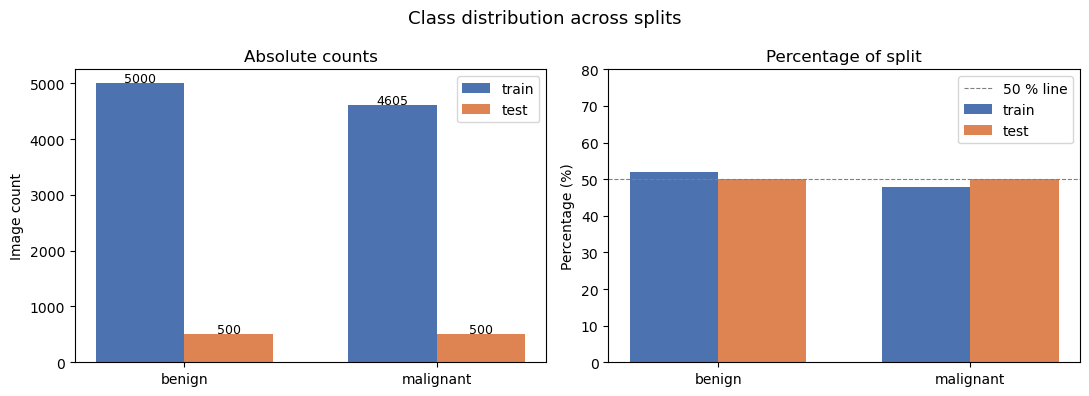

Saved → class_balance.png


In [4]:
classes = sorted(set(list(train_counts) + list(test_counts)))
x = np.arange(len(classes))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Class distribution across splits", fontsize=13)

# — Absolute counts —
ax = axes[0]
b1 = ax.bar(x - w/2, [train_counts.get(c, 0) for c in classes],
            w, label="train", color="#4C72B0")
b2 = ax.bar(x + w/2, [test_counts.get(c, 0) for c in classes],
            w, label="test",  color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel("Image count"); ax.set_title("Absolute counts"); ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(int(bar.get_height())), ha="center", fontsize=9)

# — Percentages —
ax = axes[1]
ax.bar(x - w/2, [100*train_counts.get(c,0)/train_total for c in classes],
       w, label="train", color="#4C72B0")
ax.bar(x + w/2, [100*test_counts.get(c,0)/test_total for c in classes],
       w, label="test",  color="#DD8452")
ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, label="50 % line")
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel("Percentage (%)"); ax.set_title("Percentage of split")
ax.set_ylim(0, 80); ax.legend()

plt.tight_layout()
plt.savefig("class_balance.png", dpi=150)
plt.show()
print("Saved → class_balance.png")


## 3 · Transforms
**Training** uses augmentation to help the model generalise.
**Evaluation** (val + test) uses only resize + centre-crop — no randomness —
so metrics are deterministic and comparable across runs.

Design choices specific to dermoscopy:
- `RandomRotation(20)` — lesions have no canonical orientation
- `ColorJitter` with small `saturation=0.1, hue=0.05` — lesion colour carries
  diagnostic meaning, so we only nudge it slightly
- No `RandomResizedCrop` — we use `Resize → RandomCrop` to preserve aspect ratio


In [5]:
train_transform = transforms.Compose([
    # Resize slightly larger, then random-crop to IMG_SIZE.
    # Avoids aspect-ratio distortion vs RandomResizedCrop.
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20),
                       interpolation=InterpolationMode.BILINEAR),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    # Keep colour jitter mild — lesion colour is diagnostically meaningful
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20),
                       interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("train_transform:", train_transform)
print()
print("eval_transform: ", eval_transform)


train_transform: Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

eval_transform:  Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 4 · Load datasets & stratified val/test split
The original `test/` folder (1 000 images) is split into:

| Set | Size | Purpose |
|-----|------|---------|
| **val** | 500 (250 + 250) | Monitor training, save best checkpoint |
| **test** | 500 (250 + 250) | Final evaluation only — never seen during training |

Splitting the test folder (rather than train) keeps val images augmentation-free,
giving a cleaner generalisation signal during training.


In [6]:
def stratified_split(dataset, val_fraction: float, seed: int):
    """
    Split dataset indices into two groups, preserving class proportions.
    Returns (val_indices, test_indices).
    """
    rng = random.Random(seed)
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices.setdefault(label, []).append(idx)

    val_idx, test_idx = [], []
    for label, indices in class_indices.items():
        indices = indices.copy()
        rng.shuffle(indices)
        split = int(len(indices) * val_fraction)
        val_idx.extend(indices[:split])
        test_idx.extend(indices[split:])

    return val_idx, test_idx


# Load raw datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_pool     = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

# Class metadata (driven by train set)
class_names  = train_dataset.classes        # ['benign', 'malignant']
class_to_idx = train_dataset.class_to_idx   # {'benign': 0, 'malignant': 1}

# Stratified split
val_indices, test_indices = stratified_split(test_pool, VAL_FRACTION, SEED)
val_dataset  = Subset(test_pool, val_indices)
test_dataset = Subset(test_pool, test_indices)

# Helper to count classes inside a Subset
def subset_class_counts(subset):
    counts = Counter()
    for idx in subset.indices:
        _, label = subset.dataset.samples[idx]
        counts[class_names[label]] += 1
    return dict(counts)

print(f"Class mapping : {class_to_idx}")
print(f"Class names   : {class_names}")
print()
print(f"train  : {len(train_dataset):>5} images  {dict(train_counts)}")
print(f"val    : {len(val_dataset):>5} images  {subset_class_counts(val_dataset)}")
print(f"test   : {len(test_dataset):>5} images  {subset_class_counts(test_dataset)}")


Class mapping : {'benign': 0, 'malignant': 1}
Class names   : ['benign', 'malignant']

train  :  9605 images  {'benign': 5000, 'malignant': 4605}
val    :   500 images  {'benign': 250, 'malignant': 250}
test   :   500 images  {'benign': 250, 'malignant': 250}


## 5 · Class weights
Inverse-frequency formula: **w_i = N / (C × n_i)**

With a balanced dataset these will all be ≈ 1.0, so they have no effect.
They are computed here so the same code works if you swap in an imbalanced dataset later.


In [7]:
train_labels = [label for _, label in train_dataset.samples]
label_counts = Counter(train_labels)
n_total      = len(train_labels)
n_classes    = len(label_counts)

class_weights = torch.tensor(
    [n_total / (n_classes * label_counts[i]) for i in range(n_classes)],
    dtype=torch.float32,
)

print("Class weights (used in CrossEntropyLoss):")
for cls, idx in class_to_idx.items():
    print(f"  {cls:>12}  (idx {idx})  →  weight {class_weights[idx]:.4f}")

print()
print("Weight close to 1.0 = balanced class.")
print("Weight > 1.0 = minority class (model penalised more for getting it wrong).")


Class weights (used in CrossEntropyLoss):
        benign  (idx 0)  →  weight 0.9605
     malignant  (idx 1)  →  weight 1.0429

Weight close to 1.0 = balanced class.
Weight > 1.0 = minority class (model penalised more for getting it wrong).


## 6 · Build DataLoaders

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,     # avoids a tiny final batch skewing batch-norm stats
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"train_loader : {len(train_loader)} batches × {BATCH_SIZE} = {len(train_loader)*BATCH_SIZE} images/epoch")
print(f"val_loader   : {len(val_loader)} batches")
print(f"test_loader  : {len(test_loader)} batches")


train_loader : 300 batches × 32 = 9600 images/epoch
val_loader   : 16 batches
test_loader  : 16 batches


## 7 · Sanity check — inspect one batch

In [12]:
images, labels = next(iter(train_loader))

print("Batch shape  :", tuple(images.shape))   # (32, 3, 224, 224)
print("Labels       :", labels.tolist())
print("Label counts :", Counter(labels.tolist()))
print(f"Pixel range  : [{images.min():.3f}, {images.max():.3f}]")
print("dtype        :", images.dtype)


Batch shape  : (32, 3, 224, 224)
Labels       : [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Label counts : Counter({0: 21, 1: 11})
Pixel range  : [-2.118, 2.640]
dtype        : torch.float32


 7a · Visualise a sample of augmented training images

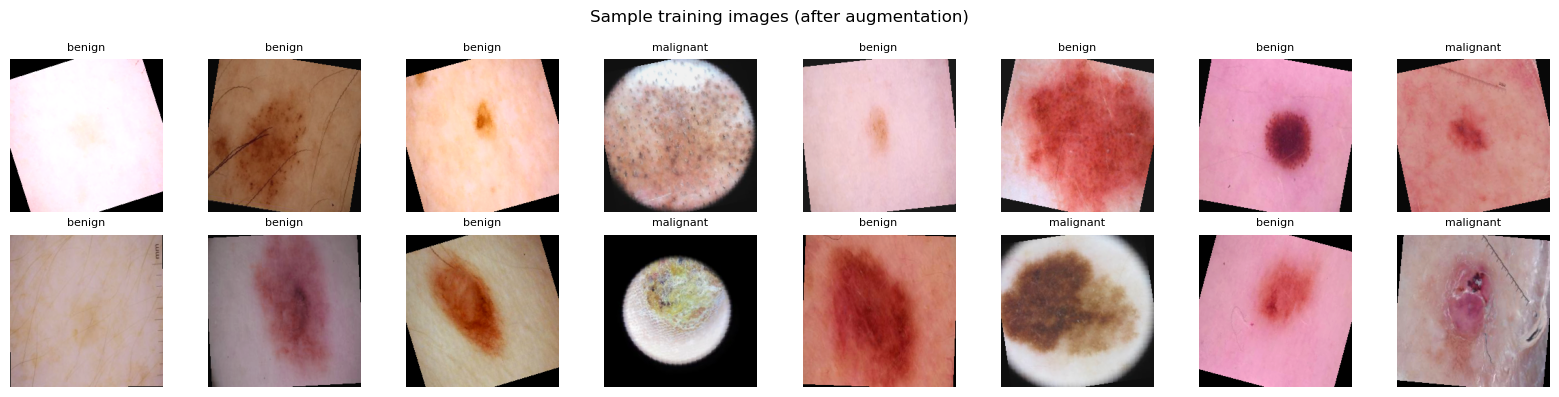

Saved → sample_batch.png


In [13]:
def denormalise(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle("Sample training images (after augmentation)", fontsize=12)

for i, ax in enumerate(axes.flat):
    img = denormalise(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_batch.png", dpi=120)
plt.show()
print("Saved → sample_batch.png")
